In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [34]:
class KMeans:
    
    def __init__(self, n_clusters, max_iter = 100, tol = 1e-4):
        self.k = n_clusters
        self.max_iter = max_iter
        self.tol = tol


    def assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis = 2)
        return np.argmin(distances, axis = 1)


    def fit_random(self, X):
        rand_idx = np.random.choice(len(X), self.k, replace = False)
        self.centroids = X[rand_idx]
        for i in range(self.max_iter):
          labels = self.assign_clusters(X)
          new_centroids = np.array([X[labels == i].mean(axis = 0) for i in range(self.k)])
          shift = np.linalg.norm(self.centroids - new_centroids)
          if shift < self.tol:
            break
          self.centroids = new_centroids
        self.labels_ = labels


    def plusplus(self, X):
        centroids = [X[np.random.choice(len(X))]]
        for _ in range(1,self.k):
            distances = np.min([np.linalg.norm(X - c, axis = 1)**2 for c in centroids], axis=0)
            probs = distances/distances.sum()
            nxt_c_idx = np.random.choice(len(X), p = probs)
            centroids.append(X[nxt_c_idx])
        return np.array(centroids)
        
    def fit_pp(self, X):
        self.centroids = self.plusplus(X)
        for i in range(self.max_iter):
            labels = self.assign_clusters(X)
            new_centroids = np.array([
                    X[labels == j].mean(axis = 0) if sum(labels == j) > 0 else self.centroids[j] 
                    for j in range(self.k)])
            shift = np.linalg.norm(self.centroids - new_centroids)
            if shift < self.tol:
                break
            self.centroids = new_centroids
        self.labels_ = labels

In [35]:
data = load_breast_cancer()
df_cancer = pd.DataFrame(data['data'])
df_cancer.columns = ['f' + str(i) for i in range(len(df_cancer.columns))]
df_cancer = df_cancer.assign(labels = data['target'])
df_cancer.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f21,f22,f23,f24,f25,f26,f27,f28,f29,labels
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [36]:
X = df_cancer.iloc[:, :-1]
std_X = StandardScaler().fit_transform(X.values)
X = pd.DataFrame(std_X)

In [37]:
obj = KMeans(n_clusters = 2)
obj.fit_random(X.values)

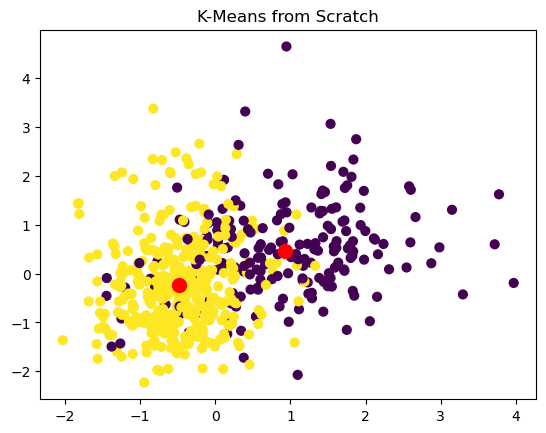

In [38]:
X_arr = X.values
plt.scatter(X_arr[:,0], X_arr[:,1], c = obj.labels_, s = 40)
plt.scatter(obj.centroids[:, 0], obj.centroids[:, 1], c='red', marker='o', s=100)
plt.title("K-Means from Scratch")
plt.show()

In [39]:
obj.fit_pp(X_arr)

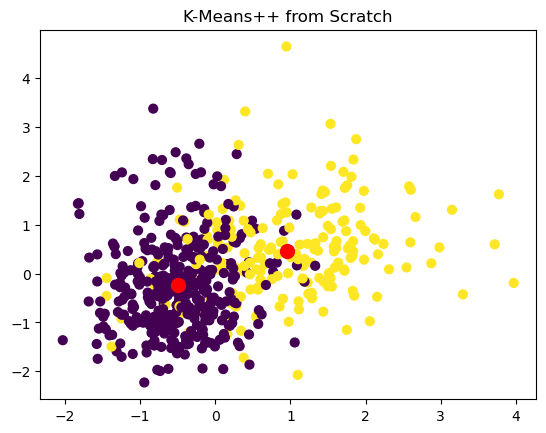

In [40]:
plt.scatter(X_arr[:,0], X_arr[:,1], c = obj.labels_, s = 40)
plt.scatter(obj.centroids[:, 0], obj.centroids[:, 1], c='red', marker='o', s=100)
plt.title("K-Means++ from Scratch")
plt.show()